**Задание:**
```txt
Write a program that trains Word2Vec model. Do not use print() instructions in your code, otherwise test procedure will not succeed; the message "Wrong Answer" indicates answer format is incorrect (print() in the code, missing words in the dictionary, etc.). The message "Embeddings are not good enough" means you're on the right track and you should focus on the model improvement.

You may think of the input string as being pre-processed with the following function:
```
```python
import re

import string

def clean(inp: str) -> str:

    inp = inp.translate(str.maketrans(string.punctuation, " "*len(string.punctuation)))

    inp = re.sub(r'\s+', ' ', inp.lower())

    return inp
```
```txt
I.e. given the input "Your string!" the output will be "your string ".


Input: data (string) - cleaned documents without punctuation in one line
Output: w2v_dict (dict: key (string) - a word from vocabulary, value (numpy array) - the word's embedding)
```

In [2]:
import re

import string

def clean(inp: str) -> str:

    inp = inp.translate(str.maketrans(string.punctuation, " "*len(string.punctuation)))

    inp = re.sub(r'\s+', ' ', inp.lower())

    return inp

In [86]:
import torch
import torch.nn as nn
from tqdm import tqdm

In [104]:
probs = torch.tensor([[-100., 1.], [-100., 1.]])
labels = torch.tensor([1, 1])
loss = nn.CrossEntropyLoss()
loss(probs, labels)

tensor(0.)

In [78]:
class Word2Vec(nn.Module):
    def __init__(self, vocab_size=1000, emb_size=100):
        super().__init__()
        self.emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=emb_size)
    def forward(self, x):
        x = self.emb(x)
        return torch.einsum('nk,vk->nv', x, self.emb.weight)

In [79]:
corpus = 'I saw a cat on a mat.'
corpus = clean(corpus)
corpus

'i saw a cat on a mat '

In [80]:
def word2idx_fit(inp: str):
    word2idx = {}
    for word in inp.split():
        if not word in word2idx:
            word2idx[word] = len(word2idx)
    return word2idx

def word2idx_transform(word2idx: dict, inp: str):
    data = [word2idx[word] for word in inp.split()]
    return torch.tensor(data)

def word2idx_fit_transform(inp: str):
    word2idx = word2idx_fit(inp)
    data = word2idx_transform(word2idx, inp)
    return data

def get_batch(tokens: torch.tensor, window_size: int = 2):
    batch = []
    for i in range(len(tokens)):
        start = max(0, i - window_size)
        stop = min(len(tokens) - 1, i + window_size)
        for j in range(start, stop + 1):
            if i == j:
                continue
            batch.append([tokens[i], tokens[j]])
    return torch.tensor(batch).T

In [83]:
word2vec = Word2Vec(vocab_size=6, emb_size=4)
tokens = word2idx_fit_transform(corpus)
word2vec(tokens)

tensor([[ 1.4571,  1.0210,  1.6125, -0.1488,  0.9627,  0.1549],
        [ 1.0210,  4.0665,  2.4872, -0.7686,  0.3507, -0.8313],
        [ 1.6125,  2.4872,  3.2794,  0.1536,  2.5753, -2.5046],
        [-0.1488, -0.7686,  0.1536,  0.5120,  0.9843, -1.2520],
        [ 0.9627,  0.3507,  2.5753,  0.9843,  3.6841, -4.2300],
        [ 1.6125,  2.4872,  3.2794,  0.1536,  2.5753, -2.5046],
        [ 0.1549, -0.8313, -2.5046, -1.2520, -4.2300,  7.0009]],
       grad_fn=<ViewBackward0>)

In [161]:
def train(doc: str):
    word2idx = word2idx_fit(doc)
    tokens = word2idx_transform(word2idx, doc)
    vocab_size = len(word2idx)
    word2vec = Word2Vec(vocab_size=vocab_size, emb_size=100)
    opt = torch.optim.Adam(word2vec.parameters())
    loss_fn = nn.CrossEntropyLoss()
    n_epohs = 10000
    loss_history = []
    for i in tqdm(range(n_epohs)):
        opt.zero_grad()
        x, y_gt = get_batch(tokens)
        y_pred = word2vec(x)
        loss = loss_fn(y_pred, y_gt)
        loss.backward()
        opt.step()
        loss_history.append(loss.item())
    embs = word2vec.emb.weight.detach().numpy()
    word2vec_dict = {}
    for word in word2idx.keys():
        word2vec_dict[word] = embs[word2idx[word]]
    return word2vec_dict

In [162]:
word2vec_dict = train(corpus)

100%|██████████| 10000/10000 [00:02<00:00, 4195.36it/s]


In [165]:
word2vec_dict['saw']

array([ 0.29686368, -0.57455456,  0.00391983,  0.01449079,  0.23953372,
       -0.33127922,  0.92404306,  0.690855  , -0.45970398, -0.03375357,
       -0.46226934, -0.5780121 , -0.4063103 ,  0.07709213,  0.34159482,
        0.27866828, -0.55138004, -1.0822128 , -0.00676214, -0.14315417,
       -0.24955969,  0.37023288,  0.2208083 , -0.7599342 , -0.59761816,
       -1.3174508 ,  0.2280881 , -0.85395074, -0.10875122, -0.60398483,
        0.29650468, -1.1288157 , -0.00525064, -0.60763377,  0.12911999,
        0.6848647 ,  0.22895607, -0.7437252 , -0.6932571 ,  0.54905427,
       -0.20859045, -0.07088125,  0.18872121,  0.11123851, -0.1638221 ,
       -0.5845656 , -0.57815653,  0.6297116 ,  0.1572182 ,  0.4044527 ,
        0.19906045, -1.3672054 , -0.01747062, -0.98882574,  0.7878108 ,
       -0.0374734 , -0.18334179, -1.2940125 , -0.4644715 , -1.1886593 ,
        0.10519437, -0.7935197 , -0.28796455, -0.13019858,  0.67072767,
        0.7311767 , -0.74780285, -0.68827796,  0.6991807 ,  0.17

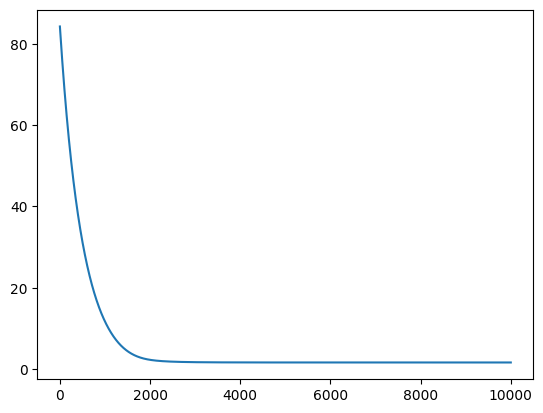

In [136]:
import matplotlib.pyplot as plt
plt.plot(loss_history)

In [137]:
model.emb.weight

Parameter containing:
tensor([[-0.0197, -0.1715,  0.9107, -0.1138, -0.5948, -0.5577, -0.6689,  0.6913,
          0.4219, -0.6649, -0.3788,  0.1710,  0.0322, -0.4894, -0.7567, -0.3199,
          0.2665, -0.1428,  0.5044, -0.7342, -0.7298,  0.4733, -0.4649, -0.8793,
         -0.3286,  0.0825,  0.4580, -0.0040, -0.9835,  0.1821,  0.1656,  0.5429,
         -0.4033,  0.3627, -0.3736,  1.1458, -0.6352,  1.4986,  0.1539, -0.4751,
          0.1769, -0.6788, -0.4186,  0.3394,  0.1080, -0.1000,  0.8040,  0.6435,
         -0.1876, -0.3624, -0.5470,  0.3192, -0.5992,  0.4120,  0.3402, -0.4361,
         -0.9798,  0.1288,  0.2068,  0.4048, -0.0648, -1.2074, -1.0409, -0.0322,
         -0.3074, -0.5729,  0.0399,  0.4370,  0.7326, -0.7309,  0.4281,  0.4689,
         -0.3373, -0.0111,  0.0174, -0.5627, -0.7266,  0.2726, -0.1902, -0.5521,
          0.5638, -0.4474, -0.7091, -0.0875,  0.8684,  0.2011, -0.7271, -0.2202,
          0.0745, -1.0312, -0.0764, -0.3775,  0.7405,  0.4405,  0.2365, -1.0543,
      

In [126]:
loss_history

[98.9454345703125,
 98.76172637939453,
 98.57831573486328,
 98.39518737792969,
 98.21231079101562,
 98.02971649169922,
 97.84744262695312,
 97.6654281616211,
 97.48368835449219,
 97.3022689819336,
 97.12114715576172,
 96.9403076171875,
 96.7597885131836,
 96.5795669555664,
 96.3996353149414,
 96.22004699707031,
 96.040771484375,
 95.8617935180664,
 95.68315124511719,
 95.50481414794922,
 95.32683563232422,
 95.149169921875,
 94.97180938720703,
 94.7948226928711,
 94.61813354492188,
 94.4417724609375,
 94.2657470703125,
 94.0900650024414,
 93.91470336914062,
 93.73970031738281,
 93.56503295898438,
 93.39067840576172,
 93.21668243408203,
 93.04302215576172,
 92.86969757080078,
 92.69672393798828,
 92.52407836914062,
 92.35177612304688,
 92.17981719970703,
 92.0082015991211,
 91.83692932128906,
 91.66598510742188,
 91.4953842163086,
 91.32513427734375,
 91.15519714355469,
 90.98562622070312,
 90.81639099121094,
 90.64747619628906,
 90.47891235351562,
 90.31067657470703,
 90.14277648925781

In [50]:
get_batch(word2idx_fit_transform(corpus))

tensor([[0, 0, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 2, 2, 2, 5, 5],
        [1, 2, 0, 2, 3, 0, 1, 3, 4, 1, 2, 4, 2, 2, 3, 2, 5, 3, 4, 5, 4, 2]])

In [29]:
model = word2vec(vocab_size=6, emb_size=6)
x = torch.tensor([0, 1, 2])
x = word2idx_fit_transform(corpus)
model(x)

tensor([[-0.0290, -2.1234,  0.1024,  1.7762, -1.2176, -0.4326],
        [ 0.7953,  1.0954,  1.0168, -0.1866,  0.5596, -0.2327],
        [-0.3037,  0.2956,  0.6494, -0.5305, -0.9752, -1.4390],
        [ 1.4390,  1.5365, -0.2586,  0.3468,  0.3704,  1.2181],
        [ 0.6070,  0.9931,  0.2894, -1.6074,  0.7270,  0.9385],
        [-0.3037,  0.2956,  0.6494, -0.5305, -0.9752, -1.4390],
        [ 0.5922,  0.2785, -0.2750, -0.7913,  0.9739, -0.2530]],
       grad_fn=<EmbeddingBackward0>)

In [143]:
model.emb.weight[0]

tensor([-0.0197, -0.1715,  0.9107, -0.1138, -0.5948, -0.5577, -0.6689,  0.6913,
         0.4219, -0.6649, -0.3788,  0.1710,  0.0322, -0.4894, -0.7567, -0.3199,
         0.2665, -0.1428,  0.5044, -0.7342, -0.7298,  0.4733, -0.4649, -0.8793,
        -0.3286,  0.0825,  0.4580, -0.0040, -0.9835,  0.1821,  0.1656,  0.5429,
        -0.4033,  0.3627, -0.3736,  1.1458, -0.6352,  1.4986,  0.1539, -0.4751,
         0.1769, -0.6788, -0.4186,  0.3394,  0.1080, -0.1000,  0.8040,  0.6435,
        -0.1876, -0.3624, -0.5470,  0.3192, -0.5992,  0.4120,  0.3402, -0.4361,
        -0.9798,  0.1288,  0.2068,  0.4048, -0.0648, -1.2074, -1.0409, -0.0322,
        -0.3074, -0.5729,  0.0399,  0.4370,  0.7326, -0.7309,  0.4281,  0.4689,
        -0.3373, -0.0111,  0.0174, -0.5627, -0.7266,  0.2726, -0.1902, -0.5521,
         0.5638, -0.4474, -0.7091, -0.0875,  0.8684,  0.2011, -0.7271, -0.2202,
         0.0745, -1.0312, -0.0764, -0.3775,  0.7405,  0.4405,  0.2365, -1.0543,
        -0.3498,  1.1661, -0.4943, -0.48

/Users/isrudnev/projects/nlp_course/.venv/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


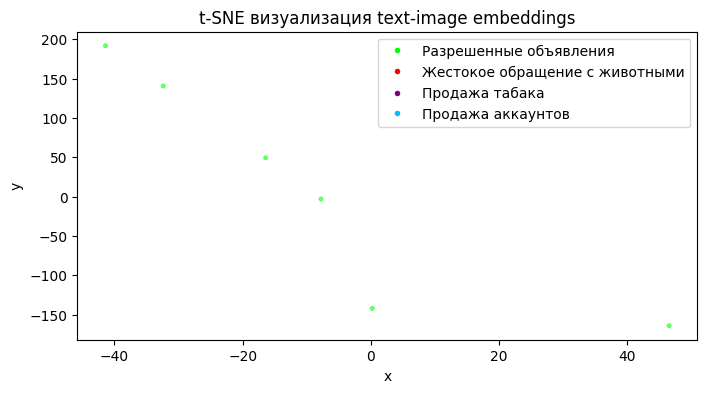

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
# Преобразуем колонку с embeddings в двумерный массив NumPy
X = model.emb.weight.detach().numpy()
y = np.zeros(X.shape[0], dtype=int)
# Применим T-SNE для уменьшения размерности до 2D
tsne = TSNE(n_components=2, perplexity=2, n_iter=1000, metric='cosine')
X_embedded = tsne.fit_transform(X)

colors = ['lime', 'purple', 'deepskyblue', 'red']
label_colors = [colors[label] for label in y]

# Визуализируем результат
plt.figure(figsize=(8, 4))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=label_colors, s=7, alpha=0.5)
plt.title('t-SNE визуализация text-image embeddings')
plt.xlabel('x')
plt.ylabel('y')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lime', markersize=5, label='Разрешенные объявления'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='Жестокое обращение с животными'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=5, label='Продажа табака'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='deepskyblue', markersize=5, label='Продажа аккаунтов'),
]

# Добавляем легенду на график
plt.legend(handles=legend_elements)
plt.savefig('output.png', dpi=400)
plt.show()

In [145]:
torch.zeros(X.shape[0])

tensor([0., 0., 0., 0., 0., 0.])

In [2]:
from word2vec import train
import matplotlib.pyplot as plt
with open('text.txt', 'r') as f:
    text = f.readlines()[0]
text

'a man and a woman received mostly positive reviews gender identity refers to an individual personal sense of identity as man or               woman man and woman arrested after male attacked a man and a woman both aged in their thirty in nature man and woman i examine the               representation of men and women by focussing on the grammatical behaviour of the noun lemmas man and woman examined the frequency with               the words man men and woman women bachelor and spinster extend to basic terms for male and female human beings she looked at man woman               and boy girl and found that negative words are used more frequently with woman girl than with man boy the four directions are the               directions north east south and west appears to rotate around an axis passing through the north and south poles of the earth in these               locations whether the sun is moving from east to west through north or south by watching its movements the sun rises eithe

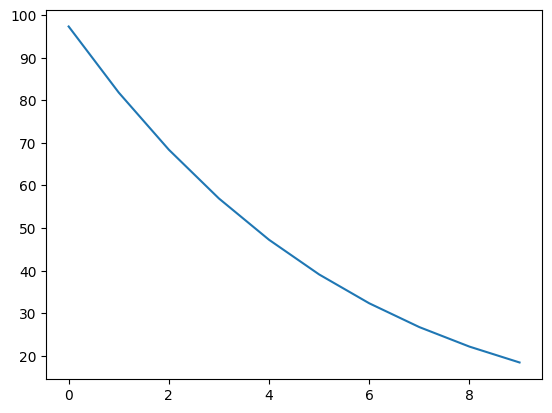

In [3]:
out, loss_history = train(text, return_history=True)

plt.plot(loss_history)